(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

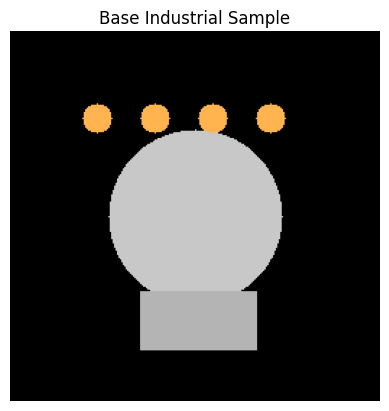

In [5]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# Create dataset folder
os.makedirs("industrial_dataset", exist_ok=True)

def create_mechanical_shape(size=256):
    img = np.zeros((size,size,3), dtype=np.uint8)

    # Gear-like circle
    cv2.circle(img, (size//2, size//2), 60, (200,200,200), -1)

    # Screw-like rectangle
    cv2.rectangle(img, (90,180), (170,220), (180,180,180), -1)

    # PCB pads
    for x in range(60,200,40):
        cv2.circle(img, (x,60), 10, (255,180,80), -1)

    return img

base = create_mechanical_shape()

plt.imshow(base)
plt.title("Base Industrial Sample")
plt.axis("off")


LIGHTING AUGMENTATIONS

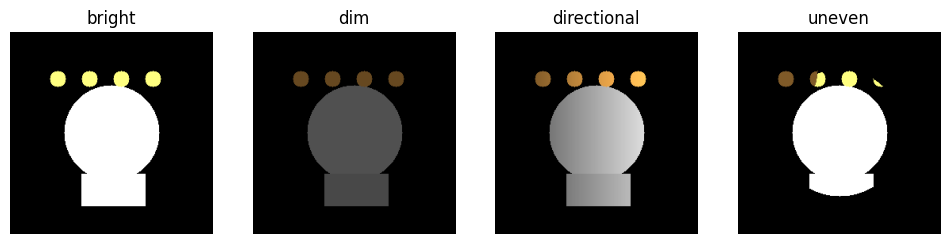

In [6]:
def bright(img, factor=1.6):
    return np.clip(img * factor, 0, 255).astype(np.uint8)

def dim(img, factor=0.4):
    return np.clip(img * factor, 0, 255).astype(np.uint8)

def directional_light(img):
    h, w = img.shape[:2]
    gradient = np.tile(np.linspace(0.3, 1.4, w), (h,1))
    out = img * gradient[...,None]
    return np.clip(out, 0, 255).astype(np.uint8)

def uneven_illumination(img):
    mask = np.zeros_like(img[:,:,0], np.float32)
    cv2.circle(mask, (128,128), 80, 1.6, -1)
    cv2.circle(mask, (50,50), 50, 0.5, -1)
    return np.clip(img * mask[...,None], 0, 255).astype(np.uint8)

lighting_variations = {
    "bright": bright(base),
    "dim": dim(base),
    "directional": directional_light(base),
    "uneven": uneven_illumination(base),
}


plt.figure(figsize=(12,3))
for i,(k,v) in enumerate(lighting_variations.items()):
    cv2.imwrite(f"industrial_dataset/{k}.png", v)
    plt.subplot(1,4,i+1)
    plt.imshow(v)
    plt.title(k)
    plt.axis("off")


LENS PARAMETER SIMULATION

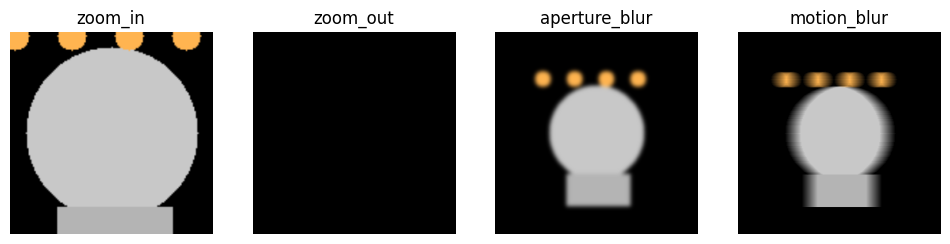

In [7]:
def focal_length(img, zoom=1.4):
    h,w = img.shape[:2]
    nh, nw = int(h/zoom), int(w/zoom)
    cropped = img[h//2 - nh//2:h//2 + nh//2, w//2 - nw//2:w//2 + nw//2]
    return cv2.resize(cropped, (w,h))

def aperture_blur(img, k=15):
    return cv2.GaussianBlur(img, (k,k), 0)


def exposure_motion_blur(img, k=20):
    kernel = np.zeros((k,k))
    kernel[int((k-1)/2), :] = 1.0 / k
    return cv2.filter2D(img, -1, kernel)

lens_variations = {
    "zoom_in": focal_length(base, zoom=1.8),
    "zoom_out": focal_length(base, zoom=0.7),
    "aperture_blur": aperture_blur(base),
    "motion_blur": exposure_motion_blur(base)
}


plt.figure(figsize=(12,3))
for i, (k,v) in enumerate(lens_variations.items()):
    cv2.imwrite(f"industrial_dataset/{k}.png", v)
    plt.subplot(1,4,i+1)
    plt.imshow(v)
    plt.title(k)
    plt.axis("off")
